# Notebook21 — Engineering Risk Assessment and CRISPR Prioritization

## Purpose

Notebook20 generated intervention recommendations for promising CHO clones.

However, biological engineering is inherently uncertain.

Not every intervention succeeds.

Some interventions generate strong improvements.
Some have little effect.
Some create unexpected tradeoffs.

This notebook introduces engineering realism by estimating:

- intervention success probability
- off-target risk
- engineering confidence
- expected net benefit

The goal is to prioritize interventions that provide the highest expected value while minimizing biological risk.

## Key Questions

- Which engineering strategy should be prioritized?
- Which interventions are low-risk and high-impact?
- Which interventions are high-risk and require caution?
- Which clones represent the strongest engineering opportunities?

By the end of this notebook, we will create an engineering portfolio ranked by gain, risk, and confidence.

## Section 1 — Load engineering recommendations

Notebook20 produced intervention recommendations and estimated engineering gains.

These recommendations become the input for engineering risk analysis.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]

engineering = pd.read_csv(
    ROOT /
    "data/synthetic/digital_twin/" /
    "notebook20_engineering_recommendations_5000_legacy.csv"
)

print(engineering.shape)

engineering.head()

(36, 12)


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision,bottleneck,recommended_intervention,post_engineering_score,engineering_gain
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance,omics,PDI_folding_support,75.317352,15.993428
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance,omics,PDI_folding_support,65.778556,14.723471
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance,productivity,XBP1s_secretory_support,60.658313,17.795377
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring,productivity,XBP1s_secretory_support,62.177485,19.546060
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring,productivity,XBP1s_secretory_support,58.627415,16.031693


## Section 2 — Define intervention risk profiles

Different interventions carry different levels of uncertainty.

This section defines:

- success probability
- off-target risk
- implementation complexity

Values are synthetic but biologically plausible.

In [3]:
risk_db = {

    "XBP1s_secretory_support": {
        "success_prob": 0.80,
        "risk": 0.15,
        "complexity": 0.40
    },

    "PDI_folding_support": {
        "success_prob": 0.75,
        "risk": 0.20,
        "complexity": 0.45
    },

    "B4GALT1_glycoengineering": {
        "success_prob": 0.85,
        "risk": 0.10,
        "complexity": 0.35
    },

    "ST6GAL1_sialylation_support": {
        "success_prob": 0.80,
        "risk": 0.10,
        "complexity": 0.40
    },

    "LDHA_overflow_reduction": {
        "success_prob": 0.60,
        "risk": 0.30,
        "complexity": 0.60
    },

    "BCL2_survival_support": {
        "success_prob": 0.70,
        "risk": 0.25,
        "complexity": 0.50
    }
}

risk_db

{'XBP1s_secretory_support': {'success_prob': 0.8,
  'risk': 0.15,
  'complexity': 0.4},
 'PDI_folding_support': {'success_prob': 0.75,
  'risk': 0.2,
  'complexity': 0.45},
 'B4GALT1_glycoengineering': {'success_prob': 0.85,
  'risk': 0.1,
  'complexity': 0.35},
 'ST6GAL1_sialylation_support': {'success_prob': 0.8,
  'risk': 0.1,
  'complexity': 0.4},
 'LDHA_overflow_reduction': {'success_prob': 0.6,
  'risk': 0.3,
  'complexity': 0.6},
 'BCL2_survival_support': {'success_prob': 0.7,
  'risk': 0.25,
  'complexity': 0.5}}

## Section 3 — Assign risk metrics

Each clone receives:

- success probability
- off-target risk
- engineering complexity

based on its recommended intervention.

In [4]:
engineering["success_probability"] = (
    engineering["recommended_intervention"]
    .map(lambda x: risk_db[x]["success_prob"])
)

engineering["off_target_risk"] = (
    engineering["recommended_intervention"]
    .map(lambda x: risk_db[x]["risk"])
)

engineering["engineering_complexity"] = (
    engineering["recommended_intervention"]
    .map(lambda x: risk_db[x]["complexity"])
)

engineering.head()

,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision,bottleneck,recommended_intervention,post_engineering_score,engineering_gain,success_probability,off_target_risk,engineering_complexity
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance,omics,PDI_folding_support,75.317352,15.993428,0.75,0.20,0.45
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance,omics,PDI_folding_support,65.778556,14.723471,0.75,0.20,0.45
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance,productivity,XBP1s_secretory_support,60.658313,17.795377,0.80,0.15,0.40
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring,productivity,XBP1s_secretory_support,62.177485,19.546060,0.80,0.15,0.40
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring,productivity,XBP1s_secretory_support,58.627415,16.031693,0.80,0.15,0.40


## Section 4 — Simulate engineering outcomes

Not every intervention succeeds.

This section simulates whether engineering was successful using the assigned success probabilities.

Successful interventions receive the full engineering gain.

Failed interventions receive a reduced or negative outcome.

In [5]:
np.random.seed(42)

engineering["engineering_success"] = (
    np.random.rand(len(engineering))
    <
    engineering["success_probability"]
)

engineering["realized_gain"] = np.where(
    engineering["engineering_success"],
    engineering["engineering_gain"],
    engineering["engineering_gain"] * np.random.uniform(
        -0.3,
        0.2,
        len(engineering)
    )
)

engineering[
    [
        "clone_id",
        "recommended_intervention",
        "engineering_gain",
        "realized_gain",
        "engineering_success"
    ]
].head()

,clone_id,recommended_intervention,engineering_gain,realized_gain,engineering_success
0,CLONE_4625,PDI_folding_support,15.993428,15.993428,True
1,CLONE_4878,PDI_folding_support,14.723471,-3.698005,False
2,CLONE_3895,XBP1s_secretory_support,17.795377,17.795377,True
3,CLONE_3895,XBP1s_secretory_support,19.546060,19.546060,True
4,CLONE_3895,XBP1s_secretory_support,16.031693,16.031693,True


## Section 5 — Calculate engineering confidence

Engineering confidence combines:

- expected success
- risk profile
- implementation complexity

Higher scores indicate more reliable engineering opportunities.

In [6]:
engineering["engineering_confidence"] = (
    engineering["success_probability"]
    *
    (1 - engineering["off_target_risk"])
    *
    (1 - engineering["engineering_complexity"])
)

engineering[
    [
        "clone_id",
        "engineering_confidence"
    ]
].head()

,clone_id,engineering_confidence
0,CLONE_4625,0.330
1,CLONE_4878,0.330
2,CLONE_3895,0.408
3,CLONE_3895,0.408
4,CLONE_3895,0.408


## Section 6 — Expected net benefit

Expected net benefit adjusts engineering gain by the probability of success.

This metric is useful for prioritizing interventions.

In [7]:
engineering["expected_net_benefit"] = (
    engineering["engineering_gain"]
    *
    engineering["success_probability"]
)

engineering[
    [
        "clone_id",
        "expected_net_benefit"
    ]
].head()

,clone_id,expected_net_benefit
0,CLONE_4625,11.995071
1,CLONE_4878,11.042604
2,CLONE_3895,14.236302
3,CLONE_3895,15.636848
4,CLONE_3895,12.825355


## Section 7 — Rank engineering opportunities

Interventions are ranked using expected net benefit.

This ranking balances gain and engineering risk.

In [8]:
ranked = (
    engineering
    .sort_values(
        "expected_net_benefit",
        ascending=False
    )
)

display(
    ranked[
        [
            "clone_id",
            "recommended_intervention",
            "engineering_gain",
            "expected_net_benefit",
            "engineering_confidence"
        ]
    ].head(20)
)

,clone_id,recommended_intervention,engineering_gain,expected_net_benefit,engineering_confidence
31,CLONE_1091,XBP1s_secretory_support,20.204556,16.163645,0.408
6,CLONE_0080,XBP1s_secretory_support,19.658426,15.726741,0.408
3,CLONE_3895,XBP1s_secretory_support,19.546060,15.636848,0.408
20,CLONE_4425,XBP1s_secretory_support,19.431298,15.545038,0.408
34,CLONE_3546,XBP1s_secretory_support,18.145090,14.516072,0.408
7,CLONE_1633,XBP1s_secretory_support,18.034869,14.427896,0.408
2,CLONE_3895,XBP1s_secretory_support,17.795377,14.236302,0.408
9,CLONE_3269,XBP1s_secretory_support,17.585120,14.068096,0.408
27,CLONE_2723,XBP1s_secretory_support,17.251396,13.801117,0.408
17,CLONE_0894,XBP1s_secretory_support,17.128495,13.702796,0.408


## Section 8 — Risk versus gain analysis

This plot visualizes the tradeoff between engineering gain and risk.

The ideal region is:

- high gain
- low risk

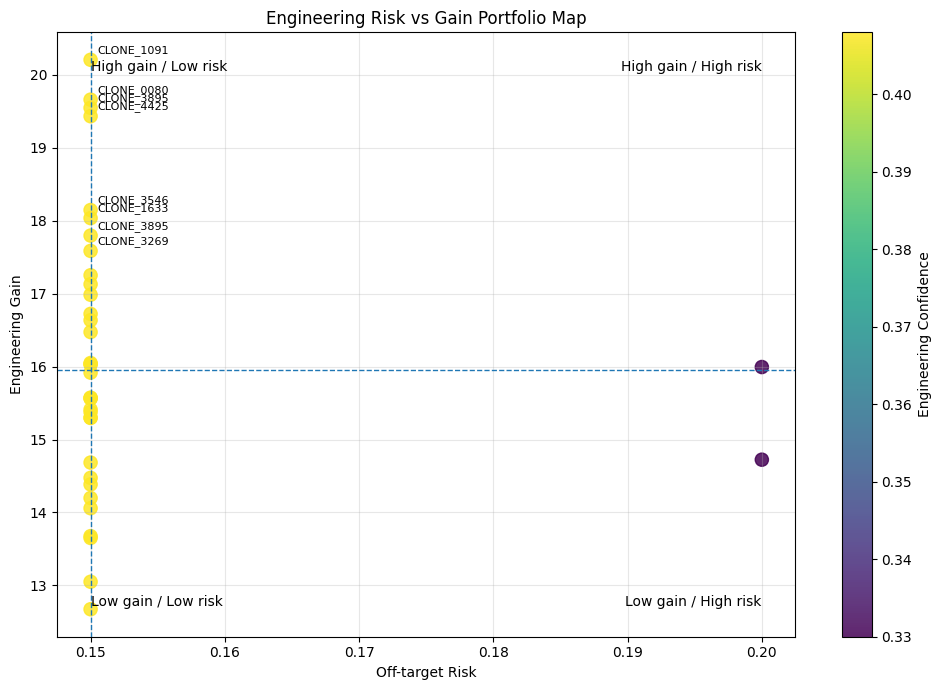

In [9]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    engineering["off_target_risk"],
    engineering["engineering_gain"],
    c=engineering["engineering_confidence"],
    s=90,
    alpha=0.85,
    cmap="viridis"
)

risk_cutoff = engineering["off_target_risk"].median()
gain_cutoff = engineering["engineering_gain"].median()

plt.axvline(
    risk_cutoff,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    gain_cutoff,
    linestyle="--",
    linewidth=1
)

for _, row in engineering.iterrows():
    if row["expected_net_benefit"] >= engineering["expected_net_benefit"].quantile(0.80):
        plt.annotate(
            row["clone_id"],
            (
                row["off_target_risk"],
                row["engineering_gain"]
            ),
            fontsize=8,
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.text(
    engineering["off_target_risk"].min(),
    engineering["engineering_gain"].max(),
    "High gain / Low risk",
    fontsize=10,
    va="top"
)

plt.text(
    engineering["off_target_risk"].max(),
    engineering["engineering_gain"].max(),
    "High gain / High risk",
    fontsize=10,
    ha="right",
    va="top"
)

plt.text(
    engineering["off_target_risk"].min(),
    engineering["engineering_gain"].min(),
    "Low gain / Low risk",
    fontsize=10,
    va="bottom"
)

plt.text(
    engineering["off_target_risk"].max(),
    engineering["engineering_gain"].min(),
    "Low gain / High risk",
    fontsize=10,
    ha="right",
    va="bottom"
)

plt.colorbar(
    scatter,
    label="Engineering Confidence"
)

plt.xlabel("Off-target Risk")
plt.ylabel("Engineering Gain")
plt.title("Engineering Risk vs Gain Portfolio Map")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9 — Engineering portfolio matrix

Interventions are grouped into strategic categories.

This helps distinguish:

- safe engineering projects
- aggressive engineering projects

In [10]:
engineering["portfolio_group"] = np.where(
    (
        engineering["off_target_risk"] < 0.20
    )
    &
    (
        engineering["engineering_gain"]
        >
        engineering["engineering_gain"].median()
    ),
    "High Gain / Low Risk",
    "Other"
)

engineering["portfolio_group"].value_counts()

portfolio_group
Other                   19
High Gain / Low Risk    17
Name: count, dtype: int64

## Section 10 — Success probability distribution

This section summarizes engineering feasibility across the clone portfolio.

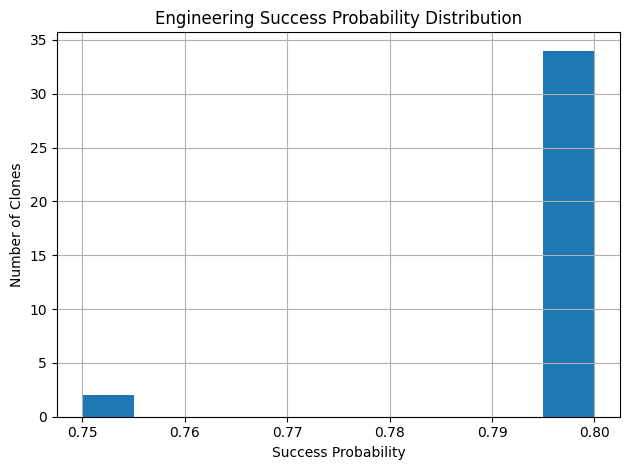

In [11]:
engineering["success_probability"].hist(
    bins=10
)

plt.title(
    "Engineering Success Probability Distribution"
)

plt.xlabel("Success Probability")

plt.ylabel("Number of Clones")

plt.tight_layout()
plt.show()

## Section 11 — Top CRISPR targets

Frequently recommended interventions highlight platform-level engineering opportunities.

In [12]:
top_targets = (
    engineering[
        "recommended_intervention"
    ]
    .value_counts()
    .reset_index()
)

top_targets.columns = [
    "target",
    "count"
]

display(top_targets)

,target,count
0,XBP1s_secretory_support,34
1,PDI_folding_support,2


## Section 12 — Engineering scorecard

This scorecard summarizes the overall engineering portfolio.

In [13]:
scorecard = pd.DataFrame({

    "metric":[
        "engineering_candidates",
        "mean_expected_benefit",
        "mean_confidence",
        "success_rate",
        "unique_interventions"
    ],

    "value":[
        len(engineering),
        round(
            engineering[
                "expected_net_benefit"
            ].mean(),
            2
        ),
        round(
            engineering[
                "engineering_confidence"
            ].mean(),
            2
        ),
        round(
            engineering[
                "engineering_success"
            ].mean(),
            2
        ),
        engineering[
            "recommended_intervention"
        ].nunique()
    ]
})

display(scorecard)

,metric,value
0,engineering_candidates,36.00
1,mean_expected_benefit,12.83
2,mean_confidence,0.40
3,success_rate,0.81
4,unique_interventions,2.00


## Section 13 — Export engineering outputs

The final engineering portfolio is exported for downstream SDL simulations and CRISPR prioritization studies.

In [14]:
out_dir = (
    ROOT /
    "data/synthetic/digital_twin"
)

engineering.to_csv(
    out_dir /
    "notebook21_engineering_risk_assessment_5000_legacy.csv",
    index=False
)

ranked.to_csv(
    out_dir /
    "notebook21_ranked_engineering_opportunities_5000_legacy.csv",
    index=False
)

scorecard.to_csv(
    out_dir /
    "notebook21_engineering_scorecard_5000_legacy.csv",
    index=False
)

print("Notebook21 exports saved.")

Notebook21 exports saved.


# Final Summary

Notebook21 introduced engineering realism into the SDL platform.

Major additions include:

- intervention success probability
- off-target risk
- engineering complexity
- realized engineering outcomes
- engineering confidence
- expected net benefit
- risk-aware prioritization

The platform now evaluates not only what intervention should be applied, but also how likely it is to succeed.

This notebook moves the project from engineering recommendation toward engineering decision-making.

# References

## CHO Cell Engineering

Wurm FM.

Production of recombinant protein therapeutics in cultivated mammalian cells.

Nature Biotechnology (2004)

DOI: 10.1038/nbt1026

---

Kim JY, Kim YG, Lee GM.

CHO cells in biotechnology for production of recombinant proteins.

Current Opinion in Biotechnology (2012)

DOI: 10.1016/j.copbio.2011.10.002

## Secretory Pathway Engineering

Ku SCY et al.

Engineering mammalian cells for enhanced recombinant protein production.

Biotechnology Advances (2008)

## Glycoengineering

Amann T et al.

Engineering glycosylation pathways in CHO cells.

Metabolic Engineering (2019)

## CRISPR and Cell Engineering

Doudna JA, Charpentier E.

The new frontier of genome engineering with CRISPR-Cas9.

Science (2014)

DOI: 10.1126/science.1258096

## Digital Twins and SDL

Narciso-da-Rocha C et al.

Digital Twins in Biopharmaceutical Manufacturing.

Biotechnology Advances (2024)

DOI: 10.1016/j.biotechadv.2024.108388

---

FDA.

PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing and Quality Assurance.

2004.